In [247]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
import yfinance as yf
import pandas as pd
import sqlite3 as db

In [248]:
ticker = yf.Ticker("GC=F")

# get historical market data
df = ticker.history(start = "2020-01-01", end = "2020-1-31" , interval = "1d")

# drop the column Dividends and Stock Splits
df = df.drop(columns = ['Dividends', 'Stock Splits'])
df

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00-05:00,1518.099976,1528.699951,1518.000000,1524.500000,214
2020-01-03 00:00:00-05:00,1530.099976,1552.699951,1530.099976,1549.199951,107
2020-01-06 00:00:00-05:00,1580.000000,1580.000000,1560.400024,1566.199951,416
2020-01-07 00:00:00-05:00,1558.300049,1576.300049,1558.300049,1571.800049,47
2020-01-08 00:00:00-05:00,1579.699951,1604.199951,1552.300049,1557.400024,236
2020-01-09 00:00:00-05:00,1555.699951,1555.699951,1543.300049,1551.699951,54
2020-01-10 00:00:00-05:00,1551.199951,1558.800049,1545.400024,1557.500000,16
2020-01-13 00:00:00-05:00,1557.400024,1558.000000,1548.400024,1548.400024,48
2020-01-14 00:00:00-05:00,1546.699951,1546.699951,1534.900024,1542.400024,32


In [249]:
# Perpindiculry important points algorithm pip
def find_pips(data: np.array, n_pips: int, dist_measure: int):
    # dist_measure
    # 1 = Euclidean Distance
    # 2 = Perpindicular Distance
    # 3 = Vertical Distance

    pips_x = [0, len(data) - 1]  # Index
    pips_y = [data[0], data[-1]] # Price

    for curr_point in range(2, n_pips):

        md = 0.0 # Max distance
        md_i = -1 # Max distance index
        insert_index = -1

        for k in range(0, curr_point - 1):

            # Left adjacent, right adjacent indices
            left_adj = k
            right_adj = k + 1

            time_diff = pips_x[right_adj] - pips_x[left_adj]
            price_diff = pips_y[right_adj] - pips_y[left_adj]
            slope = price_diff / time_diff
            intercept = pips_y[left_adj] - pips_x[left_adj] * slope;

            for i in range(pips_x[left_adj] + 1, pips_x[right_adj]):
                
                d = 0.0 # Distance
                if dist_measure == 1: # Euclidean distance
                    d =  ( (pips_x[left_adj] - i) ** 2 + (pips_y[left_adj] - data[i]) ** 2 ) ** 0.5
                    d += ( (pips_x[right_adj] - i) ** 2 + (pips_y[right_adj] - data[i]) ** 2 ) ** 0.5
                elif dist_measure == 2: # Perpindicular distance
                    d = abs( (slope * i + intercept) - data[i] ) / (slope ** 2 + 1) ** 0.5
                else: # Vertical distance    
                    d = abs( (slope * i + intercept) - data[i] )

                if d > md:
                    md = d
                    md_i = i
                    insert_index = right_adj

        pips_x.insert(insert_index, md_i)
        pips_y.insert(insert_index, data[md_i])

    return pips_x, pips_y

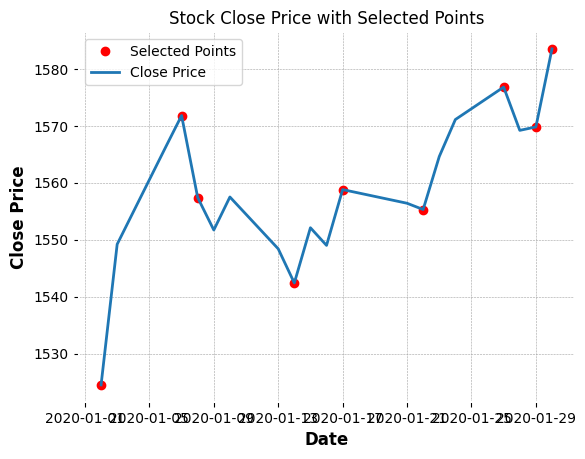

In [251]:
# convert df to numpy array
np_Df = df['Close'].to_numpy().flatten()

pips_x , pips_y = find_pips(np_Df,9,2)

# get the indecies of the dataframe corresponding to the pips_x
indeces = df.index[pips_x]

# Overlay the specific points
plt.plot(indeces , df['Close'].loc[indeces], 'ro', label='Selected Points')
# or 
#plt.plot(datetime_indices, df['Close'].iloc[pips_x], 'ro', label='Selected Points')

plt.plot(df['Close'], label='Close Price')

# Add labels and legend
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Stock Close Price with Selected Points')
plt.legend()

# Show the plot
plt.show()